# Notebook 1: Dane i przetwarzanie wstępne

## Detekcja mowy nienawiści w tekstach polskojęzycznych

**Autor:** Sebastian Śliski

**Opis:** Projekt realizuje klasyfikację tekstów pod kątem występowania mowy nienawiści (Hate Speech). Porównujemy podejście klasyczne (TF-IDF + SVM) z podejściem opartym na modelach transformatorowych (HerBERT).

**Źródło danych:** Zbiór `hate_speech_pl` z platformy Hugging Face Datasets – jest to publicznie dostępny zbiór tekstów (np. z forów i mediów społecznościowych) ocenianych przez ankieterów w skali od 0 do 4. Im wyższa wartość, tym bardziej negatywna/agresywna jest treść tekstu.

**W tym notebooku:**
1. Pobieramy i ładujemy dane.
2. Przeprowadzamy eksploracyjną analizę danych (EDA).
3. Wykonujemy przetwarzanie wstępne tekstu (m.in. czyszczenie z tagów HTML).
4. Dzielimy dane na zbiory: treningowy, walidacyjny i testowy.

## 1. Instalacja i import bibliotek

In [1]:
!pip install datasets pandas matplotlib seaborn wordcloud spacy -q
!python -m spacy download pl_core_news_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 573.7/573.7 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import html
from nltk.corpus import stopwords
import re
import spacy

## 2. Pobranie i załadowanie danych

Korzystam ze zbioru `hate_speech_pl` dostępnego na Hugging Face. Zbiór wypowiedzi z forum z ocenami od 0-4.

In [3]:
# 1. Załadowanie modelu języka polskiego z biblioteki spaCy
# Służy on do zaawansowanego przetwarzania tekstu (np. tokenizacji czy lematyzacji)
# wybór pl_core_news_lg z powodu trudnego do przetworzenia tekstu z datasetu hate_speech_pl
nlp = spacy.load('pl_core_news_lg')

# 2. Pobranie zbioru hate_speech_pl
# Parametr split="train" pobiera główną część danych, bazowo przeznaczoną do treningu
dataset = load_dataset("community-datasets/hate_speech_pl", split="train")

# 3. Konwersja formatu 'Hugging Face Dataset' do obiektu 'Pandas DataFrame'
# DataFrame znacznie ułatwia przeglądanie, filtrowanie i modyfikowanie danych
df = dataset.to_pandas()

# 4. Definicja funkcji czyszczącej teksty

import re

def quick_clean(text):
    if pd.isna(text):
        return ""

    # 1. Usuwanie tagów HTML
    clean = re.compile('<.*?>')
    text = re.sub(clean, '', str(text))

    # 2. Usuwanie słów (np. gt, lt, nbsp)
    # \b oznacza granicę słowa – dzięki temu usuniemy "gt"
    junk_words = ['gt', 'lt', 'nbsp', 'amp']
    pattern = r'\b(' + '|'.join(junk_words) + r')\b'

    # Flags=re.IGNORECASE sprawi, że usunie też 'GT', 'Gt', 'GT' itp.
    text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # 3. Dodatkowe sprzątanie: usuwanie nadmiarowych spacji,
    # które mogły powstać po usunięciu tagów lub słów
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# 4. Zastosowanie funkcji czyszczącej na kolumnie 'text'
df['text'] = df['text'].apply(quick_clean)

# Wyświetlenie podstawowych informacji o zbiorze
print(f"Liczba rekordów w zbiorze: {len(df)}")
print(f"Dostępne kolumny: {list(df.columns)}")
print("\nPodgląd pierwszych pięciu wierszy danych:")
display(df.head()) # Użycie display() renderuje w Jupyterze przejrzystą tabelę HTML


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.41k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13887 [00:00<?, ? examples/s]

Liczba rekordów w zbiorze: 13887
Dostępne kolumny: ['id', 'text_id', 'annotator_id', 'minority_id', 'negative_emotions', 'call_to_action', 'source_of_knowledge', 'irony_sarcasm', 'topic', 'text', 'rating']

Podgląd pierwszych pięciu wierszy danych:


,id,text_id,annotator_id,minority_id,negative_emotions,call_to_action,source_of_knowledge,irony_sarcasm,topic,text,rating
0,1,121713,1,72,True,True,2,True,18,Niemiec mówi co innego,0
1,2,50245,1,51,True,True,2,True,18,Za każdym razem kiedy wypływa temat homoseksua...,0
2,3,154096,1,71,True,True,2,True,4,Raczej przykład żydowskiego szowinizmu,0
3,7,99496,10,51,True,True,2,True,11,Podobno homoseksualiści mają normalny popęd se...,1
4,5,30746,1,78,True,True,2,True,15,Ukrainka zrobiła z Pazury wała,0


In [4]:
# Wybieramy kolumny: tekst recenzji i ocena (rating)
# Nazwy kolumn mogą się różnić
print("Podgląd kolumn i typów:")
print(df.dtypes)
print("\nPrzykładowe wartości:")
df.head(3)

Podgląd kolumn i typów:
id                     uint16
text_id                uint32
annotator_id            uint8
minority_id             uint8
negative_emotions        bool
call_to_action           bool
source_of_knowledge     uint8
irony_sarcasm            bool
topic                   uint8
text                   object
rating                  uint8
dtype: object

Przykładowe wartości:


,id,text_id,annotator_id,minority_id,negative_emotions,call_to_action,source_of_knowledge,irony_sarcasm,topic,text,rating
0,1,121713,1,72,True,True,2,True,18,Niemiec mówi co innego,0
1,2,50245,1,51,True,True,2,True,18,Za każdym razem kiedy wypływa temat homoseksua...,0
2,3,154096,1,71,True,True,2,True,4,Raczej przykład żydowskiego szowinizmu,0


In [5]:
# Mapowanie ocen na sentyment (binarny)
# 0 -> Neutralny (brak mowy nienawiści), 1-4 -> Mowa nienawiści
TEXT_COL = "text"
RATING_COL = "rating"

# Funkcja mapująca według Twojego schematu
def map_sentiment(rating):
    if rating == 0:
        return 0  # Neutralny / Brak mowy nienawiści
    else:
        return 1  # Mowa nienawiści

# POPRAWKA: Kopia i dodanie kolumny bezpośrednio do df_binary
df_binary = df.copy()
df_binary['sentiment'] = df_binary[RATING_COL].apply(map_sentiment)

# Sprawdzenie liczności klas
print("Rozkład nowych klas:")
print(df_binary['sentiment'].value_counts())

Rozkład nowych klas:
sentiment
0    9604
1    4283
Name: count, dtype: int64


## 3. Eksploracyjna analiza danych (EDA)

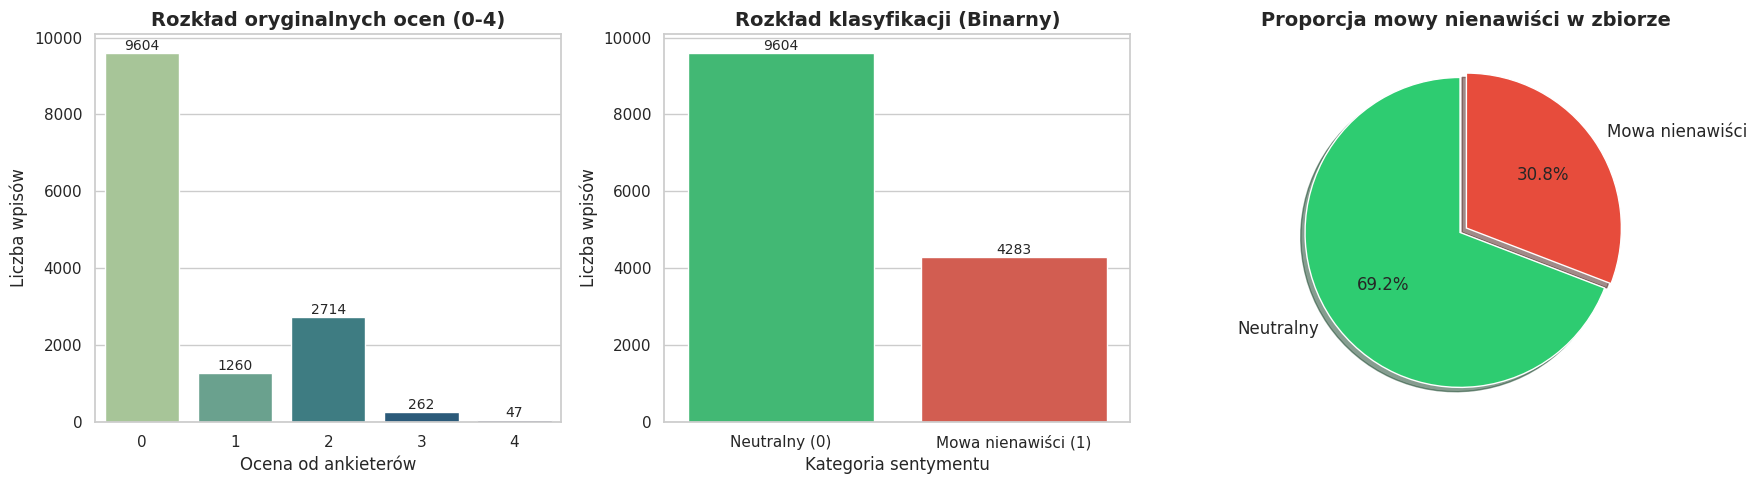

In [6]:

# Ustawienie ładnego, nowoczesnego stylu dla wykresów
sns.set_theme(style="whitegrid")

# Tworzy 3 wykresy obok siebie (1 wiersz, 3 kolumny)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- WYKRES 1: Rozkład oryginalnych ocen (0-4) ---
# Używa odcieni niebieskiego dla pokazania rosnącej intensywności ocen
sns.countplot(data=df, x=RATING_COL, hue=RATING_COL, palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Rozkład oryginalnych ocen (0-4)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Ocena od ankieterów", fontsize=12)
axes[0].set_ylabel("Liczba wpisów", fontsize=12)

# Dodanie precyzyjnych wartości nad słupkami dla łatwiejszego czytania
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# --- WYKRES 2: Rozkład binarnego sentymentu (Słupkowy) ---
# Zielony dla tekstów neutralnych, Czerwony dla mowy nienawiści
sns.countplot(data=df_binary, x='sentiment', hue='sentiment', palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Rozkład klasyfikacji (Binarny)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Kategoria sentymentu", fontsize=12)
axes[1].set_ylabel("Liczba wpisów", fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Neutralny (0)", "Mowa nienawiści (1)"])

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# --- WYKRES 3: Proporcja klas (Kołowy)
# Wykres kołowy genialnie ukazuje problem ewentualnego niezbalansowania klas w Machine Learningu
sentiment_counts = df_binary['sentiment'].value_counts()
axes[2].pie(sentiment_counts, labels=["Neutralny", "Mowa nienawiści"],
            autopct='%1.1f%%', startangle=90, colors=["#2ecc71", "#e74c3c"],
            explode=(0.05, 0), shadow=True, textprops={'fontsize': 12})
axes[2].set_title("Proporcja mowy nienawiści w zbiorze", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

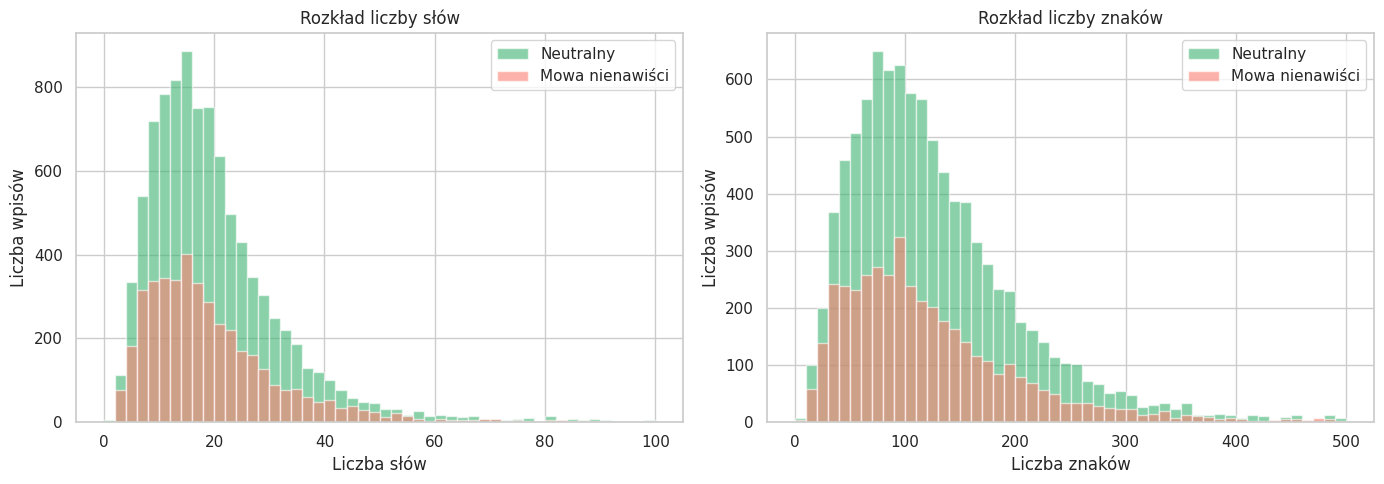

--- Statystyki długości wpisów w grupach ---


,count,mean,std,min,50%,max
Neutralny (0),9604.0,26.628905,83.532661,1.0,17.0,3443.0
Mowa nienawiści (1),4283.0,27.573897,103.083462,1.0,16.0,4107.0


In [7]:
# 1. Obliczanie długości (zabezpieczone przed błędami typu danych)
df_binary["text_length"] = df_binary["text"].astype(str).apply(len)
df_binary["word_count"] = df_binary["text"].astype(str).apply(lambda x: len(x.split()))

# 2. Przygotowanie wykresów
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Konfiguracja: (identyfikator, kolor, etykieta)
# 0 -> Neutralny (bezpieczny), 1 -> Mowa nienawiści (alarmowy)
configs = [
    (0, "mediumseagreen", "Neutralny"),
    (1, "salmon", "Mowa nienawiści")
]

for sent, color, label in configs:
    subset = df_binary[df_binary["sentiment"] == sent]
    axes[0].hist(subset["word_count"], bins=50, alpha=0.6, label=label, color=color, range=(0, 100))
    axes[1].hist(subset["text_length"], bins=50, alpha=0.6, label=label, color=color, range=(0, 500))

# Opisy osi i tytuły
axes[0].set_title("Rozkład liczby słów")
axes[0].set_xlabel("Liczba słów")
axes[0].set_ylabel("Liczba wpisów")
axes[0].legend()

axes[1].set_title("Rozkład liczby znaków")
axes[1].set_xlabel("Liczba znaków")
axes[1].set_ylabel("Liczba wpisów")
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Statystyki do raportu technicznego
print("--- Statystyki długości wpisów w grupach ---")

# Obliczamy statystyki
stats = df_binary.groupby("sentiment")["word_count"].describe()[['count', 'mean', 'std', 'min', '50%', 'max']]

# POPRAWKA: Dynamiczne mapowanie nazw
# To przypisze nazwę tylko tym klasom, które fizycznie istnieją w df
mapping = {0: "Neutralny (0)", 1: "Mowa nienawiści (1)"}
stats.index = [mapping.get(x, f"Klasa {x}") for x in stats.index]

display(stats)

## 4. Przetwarzanie wstępne tekstu

In [8]:
# Ładowanie modelu spaCy dla języka polskiego
nlp = spacy.load("pl_core_news_lg", disable=["ner", "parser"])


def preprocess_text(text):
    """Przetwarzanie wstępne tekstu: czyszczenie, lematyzacja, usunięcie stopwords."""
    if not isinstance(text, str):
        return ""

    # Zamiana na małe litery
    text = text.lower()

    # Usunięcie URL-i
    text = re.sub(r"http\S+|www\S+", "", text)

    # Usunięcie tagów HTML
    text = re.sub(r"<.*?>", "", text)

    # Usunięcie znaków specjalnych (zostawiamy litery i spacje)
    text = re.sub(r"[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]", "", text)

    # Lematyzacja i usunięcie stopwords za pomocą spaCy
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and len(token.text) > 1
    ]

    return " ".join(tokens)


# Przykład działania
sample_text = df_binary[TEXT_COL].iloc[0]
print(f"Oryginał: {sample_text[:200]}")
print(f"\nPo przetworzeniu: {preprocess_text(sample_text)[:200]}")

Oryginał: Niemiec mówi co innego

Po przetworzeniu: niemiec mówić inny


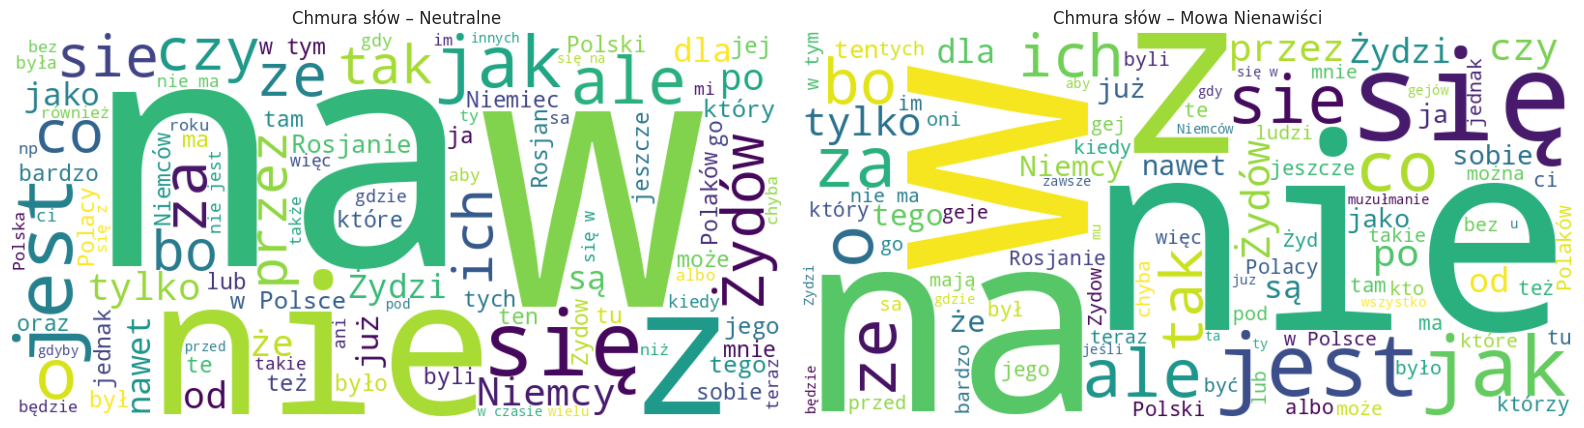

In [9]:
# Najczęstsze słowa dla każdego sentymentu
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (sent, title) in enumerate([(0, "Neutralne"), (1, "Mowa Nienawiści")]):
    texts = " ".join(df_binary[df_binary["sentiment"] == sent][TEXT_COL].astype(str))
    wc = WordCloud(
        width=800, height=400, background_color="white", max_words=100
    ).generate(texts)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Chmura słów – {title}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Przetwarzanie wstępne dla podejścia klasycznego
print("Przetwarzanie tekstu dla modelu klasycznego... (może potrwać ok. 1-2 minuty)")

# 1. Tworzymy czystą kolumnę za pomocą funkcji preprocess_text
df_binary["text_clean"] = df_binary[TEXT_COL].astype(str).apply(preprocess_text)

# 2. Usuwamy puste rekordy
# Czasami po usunięciu stop-words krótkie wpisy (np. "i co z") stają się puste
initial_count = len(df_binary)
df_binary = df_binary[df_binary["text_clean"].str.strip().str.len() > 0].reset_index(drop=True)

# 3. Informacja o odrzuconych rekordach (ważne do analizy danych - EDA 15%)
removed_count = initial_count - len(df_binary)
print(f"Usunięto {removed_count} rekordów, które stały się puste po preprocessingu.")
print(f"Rekordów po przetworzeniu: {len(df_binary)}")

# Podgląd porównawczy do raportu technicznego
display(df_binary[[TEXT_COL, "text_clean"]].head())

Przetwarzanie tekstu dla modelu klasycznego... (może potrwać ok. 1-2 minuty)
Usunięto 0 rekordów, które stały się puste po preprocessingu.
Rekordów po przetworzeniu: 13887


,text,text_clean
0,Niemiec mówi co innego,niemiec mówić inny
1,Za każdym razem kiedy wypływa temat homoseksua...,każdy raz wypływać temat homoseksualista miesz...
2,Raczej przykład żydowskiego szowinizmu,raczej przykład żydowski szowinizm
3,Podobno homoseksualiści mają normalny popęd se...,podobno homoseksualista normalny popęd seksual...
4,Ukrainka zrobiła z Pazury wała,ukrainek zrobić pazur wać


## 5. Podział na zbiory treningowy, walidacyjny i testowy

In [11]:
from sklearn.model_selection import train_test_split

# 1. Ograniczenie liczby próbek

MAX_SAMPLES = 10000

if len(df_binary) > MAX_SAMPLES:
    # Używamy train_test_split, aby wydzielić mniejszą próbkę z zachowaniem proporcji (stratify)
    df_sample, _ = train_test_split(
        df_binary,
        train_size=MAX_SAMPLES,
        random_state=42,
        stratify=df_binary["sentiment"]
    )
    print(f"Wybrano {MAX_SAMPLES} próbek z zachowaniem proporcji klas.")
else:
    df_sample = df_binary.copy()
    print(f"Używamy pełnego zbioru: {len(df_sample)} próbek.")

# 2. Właściwy podział: 70% trening, 15% walidacja, 15% test
train_df, temp_df = train_test_split(
    df_sample,
    test_size=0.3,
    random_state=42,
    stratify=df_sample["sentiment"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["sentiment"]
)

print(f"\nRozmiary zbiorów:")
print(f"  Treningowy:  {len(train_df)}")
print(f"  Walidacyjny: {len(val_df)}")
print(f"  Testowy:     {len(test_df)}")

print(f"\nRozkład klas w treningowym (powinien być zbliżony do oryginału):")
print(train_df["sentiment"].value_counts(normalize=True))

Wybrano 10000 próbek z zachowaniem proporcji klas.

Rozmiary zbiorów:
  Treningowy:  7000
  Walidacyjny: 1500
  Testowy:     1500

Rozkład klas w treningowym (powinien być zbliżony do oryginału):
sentiment
0    0.691571
1    0.308429
Name: proportion, dtype: float64


In [12]:
# Zapis przetworzonych danych do plików CSV
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Dane zapisane do plików: train.csv, val.csv, test.csv")
print("\nStruktura danych w plikach:")
print(f"  '{TEXT_COL}' - surowy tekst (do fine-tuningu Transformerów)")
print(f"  'text_clean' - tekst po lematyzacji (do modelu klasycznego TF-IDF)")
print(f"  'sentiment' - etykieta docelowa (0 = Neutralny, 1 = Mowa nienawiści)")

Dane zapisane do plików: train.csv, val.csv, test.csv

Struktura danych w plikach:
  'text' - surowy tekst (do fine-tuningu Transformerów)
  'text_clean' - tekst po lematyzacji (do modelu klasycznego TF-IDF)
  'sentiment' - etykieta docelowa (0 = Neutralny, 1 = Mowa nienawiści)


## Podsumowanie Etapu 1

W tym notebooku zrealizowaliśmy pełen potok (pipeline) przygotowania danych:

- **Pobraliśmy zbiór `hate_speech_pl`** z platformy Hugging Face (są to wpisy internetowe, a nie recenzje produktowe).
- **Uprościliśmy etykiety** zamieniając wielostopniową skalę ocen na sentyment binarny: `0` (Neutralny) oraz `1` (Mowa nienawiści).
- **Przeprowadziliśmy eksplorację danych (EDA)**, analizując m.in. niezbalansowanie klas, rozkłady długości tekstów oraz chmury najpopularniejszych słów.
- **Wykonaliśmy czyszczenie i lematyzację** za pomocą zaawansowanego modelu językowego z biblioteki `spaCy`.
- **Podzieliliśmy dane** na zbiory: treningowy (70%), walidacyjny (15%) i testowy (15%).

